In [ ]:
import pickle

# Specify the path to the pickle file you want to read
pickle_file_path = 'transaction.pkl'

# Open the pickle file in binary read mode (rb)
with open(pickle_file_path, 'rb') as file:
    # Load the data from the pickle file
    loaded_data = pickle.load(file)
# Now, the 'loaded_data' variable contains the deserialized Python object
# You can use 'loaded_data' as you would any other Python object


In [ ]:
# Filter rows where 'is_pending' is False and 'direction' is either 'INFLOW' or 'OUTFLOW'
filtered_df = loaded_data[(loaded_data['is_deleted'] == False) & ((loaded_data['direction'] == 'INFLOW') | (loaded_data['direction'] == 'OUTFLOW'))]

# Now, 'filtered_df' contains the rows where 'is_pending' is 'YANLIŞ' and 'direction' is either 'INFLOW' or 'OUTFLOW'

In [ ]:
transactions=filtered_df

In [ ]:
import pandas as pd
# Group the DataFrame by the 'account_id' column

filtered_df['new_datetime'] = pd.to_datetime(filtered_df['date'], unit='s')
grouped_by_account = filtered_df.groupby('account_id')

# Create an empty dictionary to store the tables for each account
account_tables = {}

# Iterate over the groups (one group per unique 'account_id')
for account_id, group in grouped_by_account:
    # Within each 'account_id' group, group the data by 'datetime' and 'direction'
    # and calculate the sums of 'amount' separately for 'INFLOW' and 'OUTFLOW'
    inflow = group[group['direction'] == 'INFLOW'].groupby('new_datetime')['amount'].sum()
    outflow = group[group['direction'] == 'OUTFLOW'].groupby('new_datetime')['amount'].sum()

    # Combine the 'inflow' and 'outflow' Series into a DataFrame
    inflow_df = pd.DataFrame({'Datetime': inflow.index, 'INFLOW': inflow.values})
    outflow_df = pd.DataFrame({'Datetime': outflow.index, 'OUTFLOW': outflow.values})

    # Merge the 'inflow' and 'outflow' DataFrames on 'Datetime' column with 0 fillna
    account_table = inflow_df.merge(outflow_df, on='Datetime', how='outer').fillna(0)

    # Store the table for the current account in the dictionary
    account_tables[account_id] = account_table


<ipython-input-4-ffb9c59a72af>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['new_datetime'] = pd.to_datetime(filtered_df['date'], unit='s')


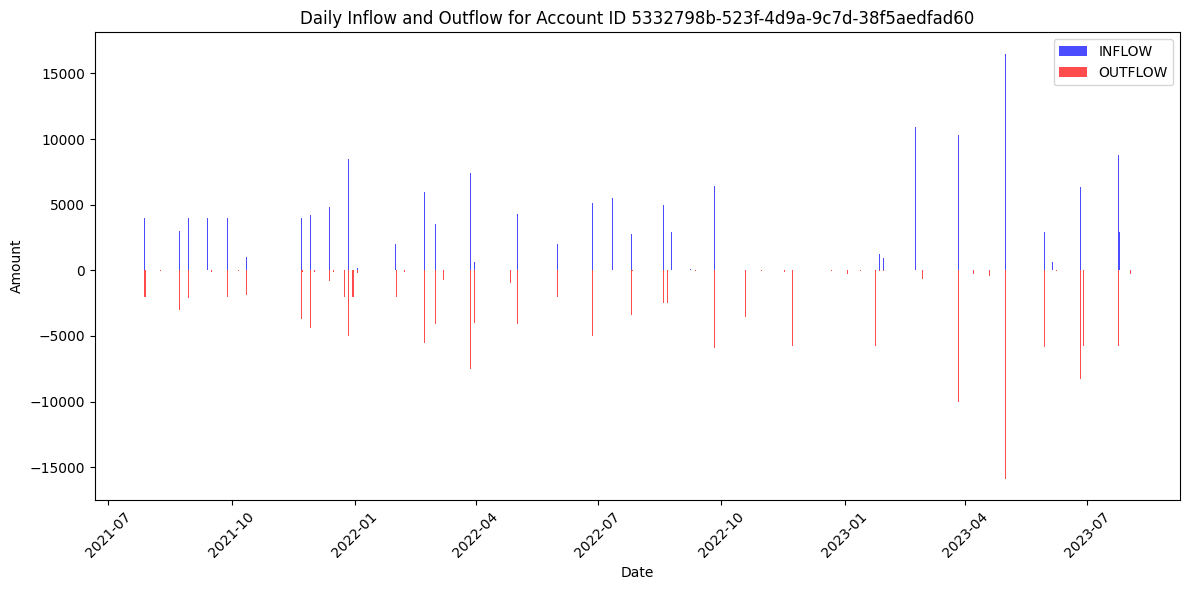

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming account_tables is a dictionary with account_id as keys and DataFrames as values
# This should be set up as described in previous conversations

# Function to generate a plot for a specific account_id
def plot_daily_inflow_outflow(account_id):
    if account_id not in account_tables:
        print(f"Account ID {account_id} not found.")
        return

    # Get the DataFrame for the specified account_id
    account_data = account_tables[account_id]

    # Plot daily inflow and outflow
    plt.figure(figsize=(12, 6))
    plt.bar(account_data['Datetime'], account_data['INFLOW'], width=0.4, label='INFLOW', color='blue', alpha=0.7)
    plt.bar(account_data['Datetime'], account_data['OUTFLOW'], width=0.4, label='OUTFLOW', color='red', alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Amount')
    plt.title(f'Daily Inflow and Outflow for Account ID {account_id}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage: Replace 'your_account_id' with the desired account_id
plot_daily_inflow_outflow('5332798b-523f-4d9a-9c7d-38f5aedfad60')


In [ ]:
import pickle
# Specify the path to the pickle file you want to read
pickle_file_path_2 = 'account.pkl'

# Open the pickle file in binary read mode (rb)
with open(pickle_file_path_2, 'rb') as file:
    # Load the data from the pickle file
    loaded_data_2 = pickle.load(file)

In [ ]:
account_balances = {}  # Create an empty dictionary
grouped_by_account_2 = loaded_data_2.groupby('id')

# Assuming account_tables is a dictionary with account_id as keys and DataFrames as values
for id, group in grouped_by_account_2:
    if id in account_tables:
        account_table = account_tables[id]  # Get the corresponding account table
        filtered_2 = loaded_data_2[loaded_data_2['id'] == id]  # Filter loaded_data_2 for the specific account_id
        if filtered_2['type'].iloc[0] == 'DEPOSIT':
          final_balance = filtered_2['balance_available_amount'].iloc[0]
          final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()

          date_range = pd.date_range(start=account_table['Datetime'].min(), end=final_date)
          account_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

          current_balance = final_balance

          table_sorted_reverse = account_table.sort_values(by='Datetime', ascending=False)

          for index, row in table_sorted_reverse.iterrows():
              inflow = row['INFLOW']
              outflow = row['OUTFLOW']
              date_ = row['Datetime']
              current_balance = current_balance - inflow + outflow
              new_row = {'date': date_, 'balance': current_balance}
              account_balance = account_balance.append(new_row, ignore_index=True)
        elif filtered_2['type'].iloc[0] == 'CREDIT':
            final_balance = filtered_2['balance_current_amount'].iloc[0]
            final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()

            date_range = pd.date_range(start=account_table['Datetime'].min(), end=final_date)
            account_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

            current_balance = final_balance

            table_sorted_reverse = account_table.sort_values(by='Datetime', ascending=False)

            for index, row in table_sorted_reverse.iterrows():
                inflow = row['INFLOW']
                outflow = row['OUTFLOW']
                date_ = row['Datetime']
                current_balance = current_balance + inflow - outflow
                new_row = {'date': date_, 'balance': current_balance}
                account_balance = account_balance.append(new_row, ignore_index=True)

        account_balance = account_balance.sort_values(by='date', ascending=True)
        account_balances[id] = account_balance

# Now, account_balances contains a dictionary where each account ID is associated with a DataFrame containing final_balance and historical_balances


<ipython-input-7-f73dfe912eb3>:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-7-f73dfe912eb3>:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-7-f73dfe912eb3>:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-7-f73dfe912eb3>:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-7-f73dfe912eb3>:26: FutureWar

In [ ]:
import pandas as pd

# Fill out the missing coloumns

for id, df in account_balances.items():
    # Convert 'date' to datetime if it's not already in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Set 'date' as index
    df.set_index('date', inplace=True)

    # Resample the data to have daily frequency
    df_resampled = df.resample('D').last()

    # Fill missing values with the last known balance (forward fill)
    df_resampled['balance'].fillna(method='ffill', inplace=True)

    # Reset index to get 'date' back as a column
    df_resampled.reset_index(inplace=True)

    # Store the modified DataFrame back in account_balances
    account_balances[id] = df_resampled

    # Print the modified DataFrame
    print(df_resampled)


          date  balance
0   2021-08-02  -899.61
1   2021-08-03  -899.61
2   2021-08-04  -899.61
3   2021-08-05  -899.61
4   2021-08-06  -899.61
..         ...      ...
727 2023-07-30   500.45
728 2023-07-31   500.51
729 2023-08-01   500.51
730 2023-08-02   500.51
731 2023-08-03   500.57

[732 rows x 2 columns]
          date    balance
0   2021-07-28 -589904.42
1   2021-07-29 -583904.42
2   2021-07-30 -583904.42
3   2021-07-31 -583904.42
4   2021-08-01 -583904.42
..         ...        ...
731 2023-07-29   -2772.00
732 2023-07-30   -2772.00
733 2023-07-31   -2772.00
734 2023-08-01   -2772.00
735 2023-08-02    3459.10

[736 rows x 2 columns]
          date    balance
0   2021-07-27  310003.97
1   2021-07-28  309347.50
2   2021-07-29  309315.28
3   2021-07-30  309267.53
4   2021-07-31  309267.53
..         ...        ...
732 2023-07-29     408.06
733 2023-07-30     408.06
734 2023-07-31     265.50
735 2023-08-01     265.50
736 2023-08-02      55.24

[737 rows x 2 columns]
          date  

In [ ]:
#Direct 90 days training
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from datetime import datetime

def feature_creation(account_id, account_balance_):
    #account_balance = account_balances.get(account_id)
    #account_balance_=account_balance.copy()

    if account_balance_ is not None:
        # Add features: previous day, two days before, three days before, seven days before
        for i in range(1, 8):  # Adding lags from 1 to 7
            account_balance_[f'lag_{i}'] = account_balance_['balance'].shift(i)

        # Calculate last 5 days mean and standard deviation
        account_balance_['last_5_days_std'] = account_balance_['balance'].rolling(window=5).std()
        account_balance_['last_30_days_std'] = account_balance_['balance'].rolling(window=30).std()
        account_balance_['last_30_days_mean'] = account_balance_['balance'].rolling(window=30).mean()
        # Calculate the average of values for the 30th and 31st day before
        account_balance_['average_value_30_31'] = account_balance_['balance'].iloc[-30:-28].mean()
        account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)

        # Remove rows with missing values after feature engineering
        account_balance_.dropna(inplace=True)

        # Standardize the data
        # scaler_X = StandardScaler()
        # scaler_y = StandardScaler()
        X = account_balance_[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std', 'last_30_days_std', 'last_30_days_mean', 'average_value_30_31', 'day_of_week', 'is_weekend']]

        y = account_balance_['balance']
        y =y.values.reshape(-1, 1)
        return account_balance_,X,y

def model_creation(X_train, y_train):
  # Build the MLP model
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.01)
    model.compile(loss='mean_squared_error', optimizer=optimizer)

    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=1, validation_split=0.2)

    return model

def predict_one_day(X_test_, y_test_,model):

    y_pred = model.predict(X_test_)

    # Inverse transform to get actual values
    #y_test = scaler_y.inverse_transform(y_test_use)
    #y_pred = scaler_y.inverse_transform(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_, y_pred))
    print(f'Root Mean Squared Error (RMSE): {rmse}')

    return y_pred, rmse

# Write the account which will be forecasted
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
account_balance = account_balances.get(account_id)
account_balance_ = account_balance.copy()
account_balance_end=account_balance.copy()

# İlk 31 satırı çıkarmak için:
#account_balance_end = account_balance_end.iloc[31:]
train_size_2 = len(account_balance_end ) - 90
account_balance_end_train, account_balance_end_test = account_balance_end[:train_size_2], account_balance_end[train_size_2:]
#standard scaler bak
account_balance_, X, y = feature_creation(account_id, account_balance_)
num=0
rmse_sum=0
if len(X) >= 90:
  train_size = len(X) - 90
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]
  model=model_creation(X_train,y_train)
  for i in range(90):
        num=num+1
        # Set the train size to leave exactly 30 data points for the test set

          # Define your column names
        columns = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std','last_30_days_std','last_30_days_mean','average_value_30_31','day_of_week', 'is_weekend']

        # Define the initial values for each column
        #iki nokta
        #account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        date = account_balance_end_test['date'].iloc[num-1]
        day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        is_weekend = 1 if date.weekday() >= 5 else 0

        #account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)
        values = [account_balance_end_train['balance'].iloc[-1], account_balance_end_train['balance'].iloc[-2],
                  account_balance_end_train['balance'].iloc[-3],account_balance_end_train['balance'].iloc[-4],
                  account_balance_end_train['balance'].iloc[-5],account_balance_end_train['balance'].iloc[-6],
                  account_balance_end_train['balance'].iloc[-7],account_balance_end_train['balance'].tail(5).std(),
                  account_balance_end_train['balance'].tail(30).std(),account_balance_end_train['balance'].tail(30).mean(),
                  account_balance_end_train['balance'].iloc[-30:-28].mean(),day_of_week,is_weekend]

        # Create a dictionary where keys are column names and values are lists of corresponding values
        data = {col: [val] for col, val in zip(columns, values)}


        # Create the DataFrame
        df = pd.DataFrame(data)
        x_test_new=df.values
        y_test_new=y_test[num-1]

        x_test_new = x_test_new.reshape(1, -1)  # Reshape X_test_ to have shape (1, num_features)
        y_test_new = y_test_new.reshape(1, -1)
        y_pred, rmse=predict_one_day(x_test_new, y_test_new,model)
        #new_row = {'date': account_balance_end_test['date'].iloc[num-1], 'balance': y_pred}
        new_row = pd.DataFrame({'date': [account_balance_end_test['date'].iloc[num-1]], 'balance': [y_pred[0][0]]})
        # Appending the new row
        account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
        rmse_sum=rmse_sum+rmse

else:
          print("Not enough data points to create a test set with 30 data points.")
          #continue

Epoch 1/100
31/31 [==============================] - 1s 6ms/step - loss: 3296133376.0000 - val_loss: 21570724.0000
Epoch 2/100
31/31 [==============================] - 0s 2ms/step - loss: 70314496.0000 - val_loss: 4780545.0000
Epoch 3/100
31/31 [==============================] - 0s 2ms/step - loss: 6845214.5000 - val_loss: 7270274.0000
Epoch 4/100
31/31 [==============================] - 0s 2ms/step - loss: 4207419.5000 - val_loss: 6957156.0000
Epoch 5/100
31/31 [==============================] - 0s 2ms/step - loss: 3719882.5000 - val_loss: 6661115.0000
Epoch 6/100
31/31 [==============================] - 0s 2ms/step - loss: 3903127.0000 - val_loss: 5332704.5000
Epoch 7/100
31/31 [==============================] - 0s 2ms/step - loss: 3237303.0000 - val_loss: 4741038.5000
Epoch 8/100
31/31 [==============================] - 0s 2ms/step - loss: 3499345.0000 - val_loss: 4513712.0000
Epoch 9/100
31/31 [==============================] - 0s 2ms/step - loss: 3086814.5000 - val_loss: 4473488.5

<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_t

1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 4578.739062499997
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 5666.093046874994
1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 5797.090703124995
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 6542.311406249995
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 7230.041953124994


<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_t

1/1 [==============================] - 0s 19ms/step
Root Mean Squared Error (RMSE): 8188.881796874994
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 8204.002109374997
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 8909.213046874997
1/1 [==============================] - 0s 21ms/step
Root Mean Squared Error (RMSE): 9653.931796874997
1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 9703.700390624996


...

<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_t

Root Mean Squared Error (RMSE): 2227.34673828125
1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 2144.742734375
1/1 [==============================] - 0s 19ms/step
Root Mean Squared Error (RMSE): 2206.448486328125
1/1 [==============================] - 0s 18ms/step
Root Mean Squared Error (RMSE): 2128.695556640625


<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_t

1/1 [==============================] - 0s 21ms/step
Root Mean Squared Error (RMSE): 2263.594228515625


<ipython-input-9-e1af62a010eb>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)


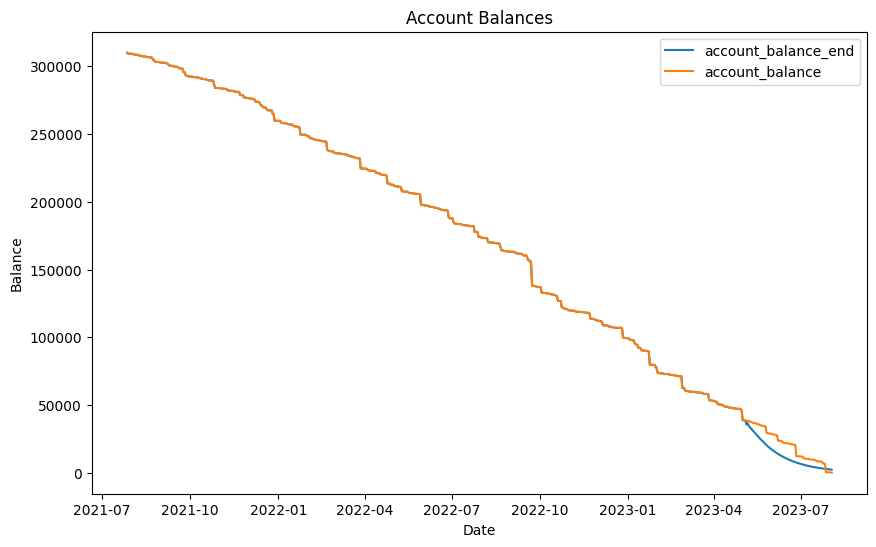

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a column in both DataFrames
plt.figure(figsize=(10, 6))
plt.plot(account_balance_end_train['date'], account_balance_end_train['balance'], label='account_balance_end')
plt.plot(account_balance['date'], account_balance['balance'], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances')
plt.legend()
plt.show()

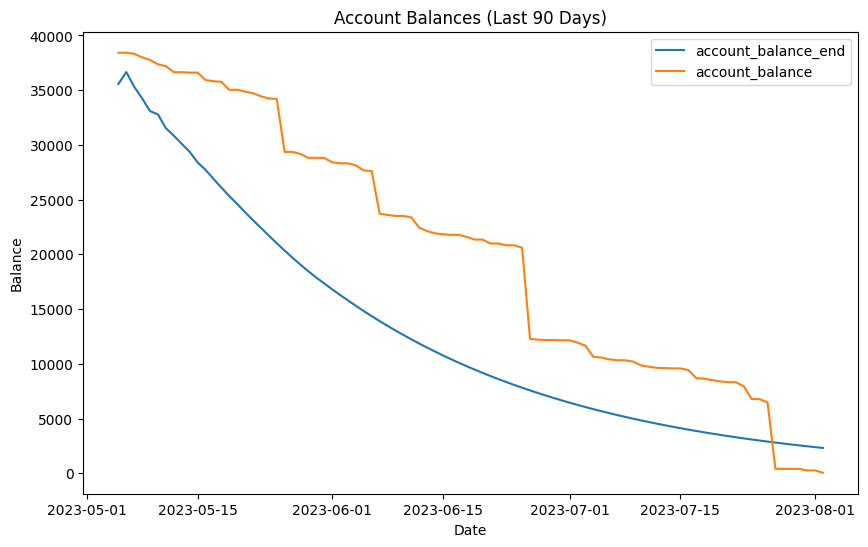

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a datetime column
last_30_days_account_balance_end = account_balance_end_train.iloc[-90:]
last_30_days_account_balance = account_balance.iloc[-90:]

plt.figure(figsize=(10, 6))
plt.plot(last_30_days_account_balance_end['date'], last_30_days_account_balance_end['balance'], label='account_balance_end')
plt.plot(last_30_days_account_balance['date'], last_30_days_account_balance['balance'], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances (Last 90 Days)')
plt.legend()
plt.show()

In [ ]:
rmse_sum/90

7608.448251627602

In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from datetime import datetime

#Direct 30 days training

def feature_creation(account_id, account_balance_):
    #account_balance = account_balances.get(account_id)
    #account_balance_=account_balance.copy()

    if account_balance_ is not None:
        # Add features: previous day, two days before, three days before, seven days before
        for i in range(1, 8):  # Adding lags from 1 to 7
            account_balance_[f'lag_{i}'] = account_balance_['balance'].shift(i)

        # Calculate last 5 days mean and standard deviation
        account_balance_['last_5_days_std'] = account_balance_['balance'].rolling(window=5).std()
        account_balance_['last_30_days_std'] = account_balance_['balance'].rolling(window=30).std()
        account_balance_['last_30_days_mean'] = account_balance_['balance'].rolling(window=30).mean()
        # Calculate the average of values for the 30th and 31st day before
        account_balance_['average_value_30_31'] = account_balance_['balance'].iloc[-30:-28].mean()
        account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)



        # Remove rows with missing values after feature engineering
        account_balance_.dropna(inplace=True)

        # Standardize the data
        # scaler_X = StandardScaler()
        # scaler_y = StandardScaler()
        X = account_balance_[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std', 'last_30_days_std', 'last_30_days_mean', 'average_value_30_31', 'day_of_week', 'is_weekend']]

        y = account_balance_['balance']
        y =y.values.reshape(-1, 1)
        return account_balance_,X,y

def model_creation(X_train, y_train):
  # Build the MLP model
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.01)
    model.compile(loss='mean_squared_error', optimizer=optimizer)

    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=1, validation_split=0.2)

    return model

def predict_one_day(X_test_, y_test_,model):

    y_pred = model.predict(X_test_)

    # Inverse transform to get actual values
    #y_test = scaler_y.inverse_transform(y_test_use)
    #y_pred = scaler_y.inverse_transform(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_, y_pred))
    print(f'Root Mean Squared Error (RMSE): {rmse}')

    return y_pred, rmse

# Write the account which will be forecasted
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
account_balance = account_balances.get(account_id)
account_balance_ = account_balance.copy()
account_balance_end=account_balance.copy()
# İlk 31 satırı çıkarmak için:
#account_balance_end = account_balance_end.iloc[31:]
train_size_2 = len(account_balance_end ) - 30
account_balance_end_train, account_balance_end_test = account_balance_end[:train_size_2], account_balance_end[train_size_2:]
#standard scaler bak
account_balance_, X, y = feature_creation(account_id, account_balance_)
num=0
rmse_sum=0
if len(X) >= 30:
  train_size = len(X) - 30
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]
  model=model_creation(X_train,y_train)
  for i in range(30):
        num=num+1
        # Set the train size to leave exactly 30 data points for the test set

          # Define your column names
        columns = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std','last_30_days_std','last_30_days_mean','average_value_30_31','day_of_week', 'is_weekend']

        # Define the initial values for each column
        #iki nokta
        #account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        date = account_balance_end_test['date'].iloc[num-1]
        day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        is_weekend = 1 if date.weekday() >= 5 else 0

        #account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)
        values = [account_balance_end_train['balance'].iloc[-1], account_balance_end_train['balance'].iloc[-2],
                  account_balance_end_train['balance'].iloc[-3],account_balance_end_train['balance'].iloc[-4],
                  account_balance_end_train['balance'].iloc[-5],account_balance_end_train['balance'].iloc[-6],
                  account_balance_end_train['balance'].iloc[-7],account_balance_end_train['balance'].tail(5).std(),
                  account_balance_end_train['balance'].tail(30).std(),account_balance_end_train['balance'].tail(30).mean(),
                  account_balance_end_train['balance'].iloc[-30:-28].mean(),day_of_week,is_weekend]

        # Create a dictionary where keys are column names and values are lists of corresponding values
        data = {col: [val] for col, val in zip(columns, values)}


        # Create the DataFrame
        df = pd.DataFrame(data)
        x_test_new=df.values
        y_test_new=y_test[num-1]

        x_test_new = x_test_new.reshape(1, -1)  # Reshape X_test_ to have shape (1, num_features)
        y_test_new = y_test_new.reshape(1, -1)
        y_pred, rmse=predict_one_day(x_test_new, y_test_new,model)
        #new_row = {'date': account_balance_end_test['date'].iloc[num-1], 'balance': y_pred}
        new_row = pd.DataFrame({'date': [account_balance_end_test['date'].iloc[num-1]], 'balance': [y_pred[0][0]]})
        # Appending the new row
        account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
        rmse_sum=rmse_sum+rmse

else:
          print("Not enough data points to create a test set with 30 data points.")
          #continue

Epoch 1/100
34/34 [==============================] - 1s 5ms/step - loss: 2048374144.0000 - val_loss: 14008840.0000
Epoch 2/100
34/34 [==============================] - 0s 2ms/step - loss: 28751776.0000 - val_loss: 6105737.5000
Epoch 3/100
34/34 [==============================] - 0s 2ms/step - loss: 4989076.0000 - val_loss: 5334442.5000
Epoch 4/100
34/34 [==============================] - 0s 2ms/step - loss: 4094240.0000 - val_loss: 4790943.0000
Epoch 5/100
34/34 [==============================] - 0s 2ms/step - loss: 3790227.2500 - val_loss: 4541407.5000
Epoch 6/100
34/34 [==============================] - 0s 2ms/step - loss: 3348184.2500 - val_loss: 3953240.5000
Epoch 7/100
34/34 [==============================] - 0s 2ms/step - loss: 3075000.5000 - val_loss: 3177346.0000
Epoch 8/100
34/34 [==============================] - 0s 2ms/step - loss: 3141308.7500 - val_loss: 2683926.5000
Epoch 9/100
34/34 [==============================] - 0s 2ms/step - loss: 2716133.2500 - val_loss: 2200595.2

<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 294.2859374999989
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 217.46347656249964
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 335.49496093749985
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 483.46316406249935
1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 681.9320703124995


<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 858.4869140624996
1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 1040.7222656249996
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 1046.6755078124988
1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 455.69636718749825


...

<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 6337.09478515625
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 5981.205625
1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 5614.6284765625
1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 5402.39654296875
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 5324.109375


<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 5133.72314453125
1/1 [==============================] - 0s 25ms/step
Root Mean Squared Error (RMSE): 5203.6769921875


<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-13-519de5cb7dee>:132: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)


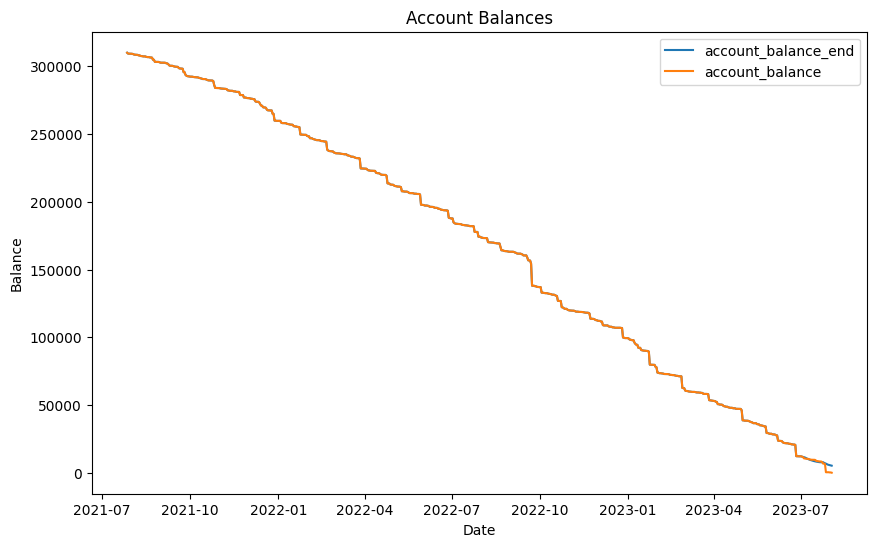

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a column in both DataFrames
plt.figure(figsize=(10, 6))
plt.plot(account_balance_end_train['date'], account_balance_end_train['balance'], label='account_balance_end')
plt.plot(account_balance['date'], account_balance['balance'], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances')
plt.legend()
plt.show()


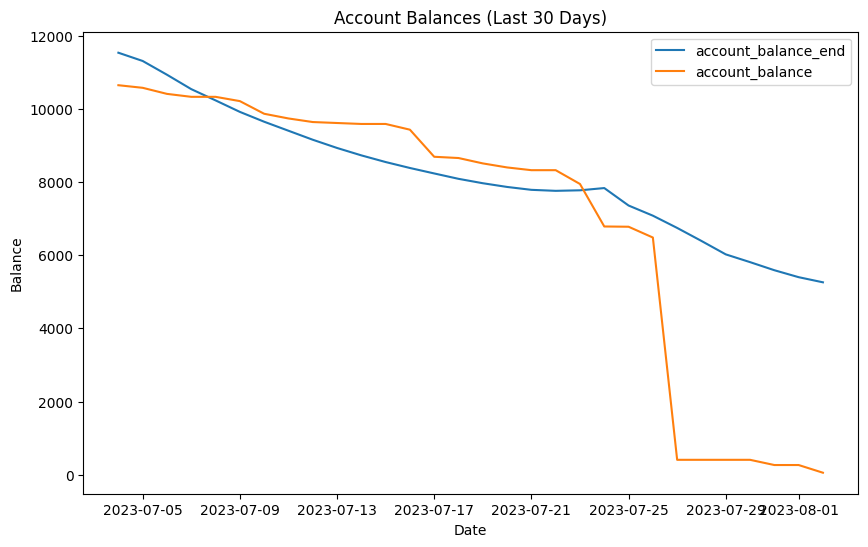

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a datetime column
last_30_days_account_balance_end = account_balance_end_train.iloc[-30:]
last_30_days_account_balance = account_balance.iloc[-30:]

plt.figure(figsize=(10, 6))
plt.plot(last_30_days_account_balance_end['date'], last_30_days_account_balance_end['balance'], label='account_balance_end')
plt.plot(last_30_days_account_balance['date'], last_30_days_account_balance['balance'], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances (Last 30 Days)')
plt.legend()
plt.show()


In [ ]:
rmse_sum/30

1733.6009492187497

In [ ]:
# First part of 30-30-30 training for 90 days forecasting
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from datetime import datetime

def feature_creation(account_id, account_balance_):
    #account_balance = account_balances.get(account_id)
    #account_balance_=account_balance.copy()

    if account_balance_ is not None:
        # Add features: previous day, two days before, three days before, seven days before
        for i in range(1, 8):  # Adding lags from 1 to 7
            account_balance_[f'lag_{i}'] = account_balance_['balance'].shift(i)

        # Calculate last 5 days mean and standard deviation
        account_balance_['last_5_days_std'] = account_balance_['balance'].rolling(window=5).std()
        account_balance_['last_30_days_std'] = account_balance_['balance'].rolling(window=30).std()
        account_balance_['last_30_days_mean'] = account_balance_['balance'].rolling(window=30).mean()
        # Calculate the average of values for the 30th and 31st day before
        account_balance_['average_value_30_31'] = account_balance_['balance'].iloc[-30:-28].mean()
        account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)



        # Remove rows with missing values after feature engineering
        account_balance_.dropna(inplace=True)

        # Standardize the data
        # scaler_X = StandardScaler()
        # scaler_y = StandardScaler()
        X = account_balance_[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std', 'last_30_days_std', 'last_30_days_mean', 'average_value_30_31', 'day_of_week', 'is_weekend']]

        y = account_balance_['balance']
        y =y.values.reshape(-1, 1)
        return account_balance_,X,y

def model_creation(X_train, y_train):
  # Build the MLP model
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='mean_squared_error', optimizer=optimizer)

    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

    return model

def predict_one_day(X_test_, y_test_,model):

    y_pred = model.predict(X_test_)

    # Inverse transform to get actual values
    #y_test = scaler_y.inverse_transform(y_test_use)
    #y_pred = scaler_y.inverse_transform(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_, y_pred))
    print(f'Root Mean Squared Error (RMSE): {rmse}')

    return y_pred, rmse

# Write the account which will be forecasted
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
account_balance = account_balances.get(account_id)
account_balance_ = account_balance.copy()
account_balance_ = account_balance_
#account_balance_=account_balance_.iloc[:-30]
account_balance_end=account_balance.copy()
# İlk 31 satırı çıkarmak için:
#account_balance_end = account_balance_end.iloc[31:]
train_size_2 = len(account_balance_end ) - 90
account_balance_end_train, account_balance_end_test = account_balance_end[:train_size_2], account_balance_end[train_size_2:train_size_2+30]
#standard scaler bak
account_balance_, X, y = feature_creation(account_id, account_balance_)
num=0
rmse_sum=0
if len(X) >= 90:
  train_size = len(X) - 90
  X_train, X_test = X[:train_size], X[train_size:train_size+30]
  y_train, y_test = y[:train_size], y[train_size:train_size+30]
  model=model_creation(X_train,y_train)
  for i in range(30):
        num=num+1
        # Set the train size to leave exactly 30 data points for the test set

          # Define your column names
        columns = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std','last_30_days_std','last_30_days_mean','average_value_30_31','day_of_week', 'is_weekend']

        # Define the initial values for each column
        #iki nokta
        #account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        date = account_balance_end_test['date'].iloc[num-1]
        day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        is_weekend = 1 if date.weekday() >= 5 else 0

        #account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)
        values = [account_balance_end_train['balance'].iloc[-1], account_balance_end_train['balance'].iloc[-2],
                  account_balance_end_train['balance'].iloc[-3],account_balance_end_train['balance'].iloc[-4],
                  account_balance_end_train['balance'].iloc[-5],account_balance_end_train['balance'].iloc[-6],
                  account_balance_end_train['balance'].iloc[-7],account_balance_end_train['balance'].tail(5).std(),
                  account_balance_end_train['balance'].tail(30).std(),account_balance_end_train['balance'].tail(30).mean(),
                  account_balance_end_train['balance'].iloc[-30:-28].mean(),day_of_week,is_weekend]

        # Create a dictionary where keys are column names and values are lists of corresponding values
        data = {col: [val] for col, val in zip(columns, values)}


        # Create the DataFrame
        df = pd.DataFrame(data)
        x_test_new=df.values
        y_test_new=y_test[num-1]

        x_test_new = x_test_new.reshape(1, -1)  # Reshape X_test_ to have shape (1, num_features)
        y_test_new = y_test_new.reshape(1, -1)
        y_pred, rmse=predict_one_day(x_test_new, y_test_new,model)
        #new_row = {'date': account_balance_end_test['date'].iloc[num-1], 'balance': y_pred}
        new_row = pd.DataFrame({'date': [account_balance_end_test['date'].iloc[num-1]], 'balance': [y_pred[0][0]]})
        # Appending the new row
        account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
        rmse_sum=rmse_sum+rmse

else:
          print("Not enough data points to create a test set with 30 data points.")
          #continue

Epoch 1/100
16/16 [==============================] - 1s 9ms/step - loss: 44219113472.0000 - val_loss: 1321945600.0000
Epoch 2/100
16/16 [==============================] - 0s 3ms/step - loss: 4884774912.0000 - val_loss: 6838855.5000
Epoch 3/100
16/16 [==============================] - 0s 3ms/step - loss: 358390176.0000 - val_loss: 86352168.0000
Epoch 4/100
16/16 [==============================] - 0s 2ms/step - loss: 163027712.0000 - val_loss: 8448222.0000
Epoch 5/100
16/16 [==============================] - 0s 4ms/step - loss: 25390456.0000 - val_loss: 6258122.5000
Epoch 6/100
16/16 [==============================] - 0s 2ms/step - loss: 9455811.0000 - val_loss: 11406735.0000
Epoch 7/100
16/16 [==============================] - 0s 2ms/step - loss: 6992440.0000 - val_loss: 10468285.0000
Epoch 8/100
16/16 [==============================] - 0s 3ms/step - loss: 5856311.0000 - val_loss: 9281899.0000
Epoch 9/100
16/16 [==============================] - 0s 2ms/step - loss: 5786644.5000 - val_lo

<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)


Root Mean Squared Error (RMSE): 8208.32
1/1 [==============================] - 0s 19ms/step
Root Mean Squared Error (RMSE): 9352.123124999998
1/1 [==============================] - 0s 20ms/step
Root Mean Squared Error (RMSE): 10257.717578124997
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 11991.483671874994


<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 13281.702031249995
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 14747.094609374995
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 16865.813437499994
1/1 [==============================] - 0s 16ms/step
Root Mean Squared Error (RMSE): 19078.075156249994
1/1 [==============================] - 0s 20ms/step


...

<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

Root Mean Squared Error (RMSE): 30950.195810546873
1/1 [==============================] - 0s 16ms/step
Root Mean Squared Error (RMSE): 30705.866708984373
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 30472.718027343748
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 29861.62943359375
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 29518.703540039063


<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 29336.273547363282


<ipython-input-20-7e12dbae4139>:135: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)


In [ ]:
  account_balance_end_train_1=account_balance_end_train
  rmse_1=rmse_sum
  print(account_balance_end_train_1)

          date        balance
0   2021-07-27  310003.970000
1   2021-07-28  309347.500000
2   2021-07-29  309315.280000
3   2021-07-30  309267.530000
4   2021-07-31  309267.530000
..         ...            ...
672 2023-05-30   -1889.126709
673 2023-05-31   -1655.978027
674 2023-06-01   -1451.919434
675 2023-06-02   -1198.753540
676 2023-06-03   -1016.323547

[677 rows x 2 columns]


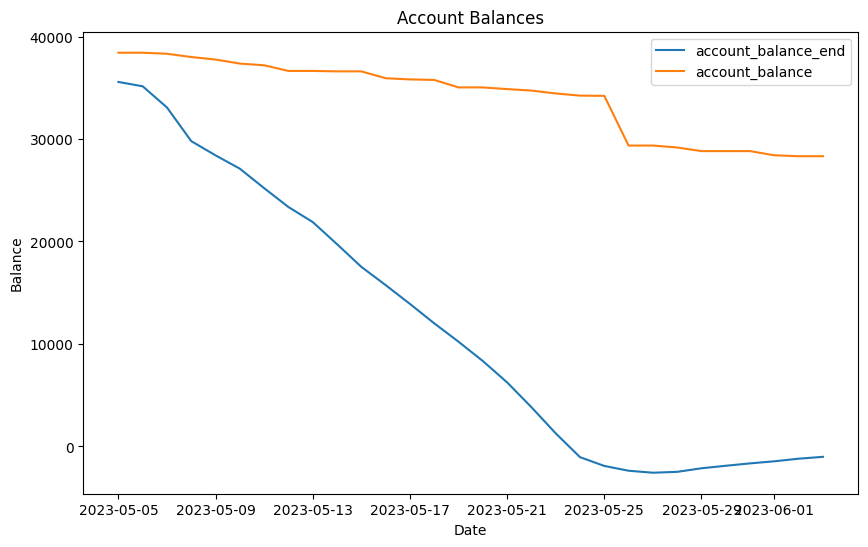

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a column in both DataFrames
plt.figure(figsize=(10, 6))
plt.plot(account_balance_end_train_1['date'][-30:], account_balance_end_train_1['balance'][-30:], label='account_balance_end')
plt.plot(account_balance['date'][-90:-60], account_balance['balance'][-90:-60], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances')
plt.legend()
plt.show()

In [ ]:
# Second part of 30-30-30 training for 90 days forecasting
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from datetime import datetime


def feature_creation(account_id, account_balance_):
    #account_balance = account_balances.get(account_id)
    #account_balance_=account_balance.copy()

    if account_balance_ is not None:
        # Add features: previous day, two days before, three days before, seven days before
        for i in range(1, 8):  # Adding lags from 1 to 7
            account_balance_[f'lag_{i}'] = account_balance_['balance'].shift(i)

        # Calculate last 5 days mean and standard deviation
        account_balance_['last_5_days_std'] = account_balance_['balance'].rolling(window=5).std()
        account_balance_['last_30_days_std'] = account_balance_['balance'].rolling(window=30).std()
        account_balance_['last_30_days_mean'] = account_balance_['balance'].rolling(window=30).mean()
        # Calculate the average of values for the 30th and 31st day before
        account_balance_['average_value_30_31'] = account_balance_['balance'].iloc[-30:-28].mean()
        account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)



        # Remove rows with missing values after feature engineering
        account_balance_.dropna(inplace=True)

        # Standardize the data
        # scaler_X = StandardScaler()
        # scaler_y = StandardScaler()
        X = account_balance_[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std', 'last_30_days_std', 'last_30_days_mean', 'average_value_30_31', 'day_of_week', 'is_weekend']]

        y = account_balance_['balance']
        y =y.values.reshape(-1, 1)
        return account_balance_,X,y

def model_creation(X_train, y_train):
  # Build the MLP model
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='mean_squared_error', optimizer=optimizer)

    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

    return model

def predict_one_day(X_test_, y_test_,model):

    y_pred = model.predict(X_test_)

    # Inverse transform to get actual values
    #y_test = scaler_y.inverse_transform(y_test_use)
    #y_pred = scaler_y.inverse_transform(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_, y_pred))
    print(f'Root Mean Squared Error (RMSE): {rmse}')

    return y_pred, rmse

# Write the account which will be forecasted
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
account_balance = account_balances.get(account_id)
account_balance_ = account_balance.copy()
#account_balance_=account_balance_.iloc[:-30]
account_balance_end=account_balance.copy()
# İlk 31 satırı çıkarmak için:
#account_balance_end = account_balance_end.iloc[31:]
train_size_2 = len(account_balance_end ) - 60
account_balance_end_train, account_balance_end_test = account_balance_end[:train_size_2], account_balance_end[train_size_2:(train_size_2+30)]
#standard scaler bak
account_balance_, X, y = feature_creation(account_id, account_balance_)
num=0
rmse_sum=0
if len(X) >= 60:
  train_size = len(X) - 60
  X_train, X_test = X[:train_size], X[train_size:(train_size+30)]
  y_train, y_test = y[:train_size], y[train_size:(train_size+30)]
  model=model_creation(X_train,y_train)
  for i in range(30):
        num=num+1
        # Set the train size to leave exactly 30 data points for the test set

          # Define your column names
        columns = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std','last_30_days_std','last_30_days_mean','average_value_30_31','day_of_week', 'is_weekend']

        # Define the initial values for each column
        #iki nokta
        #account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        date = account_balance_end_test['date'].iloc[num-1]
        day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        is_weekend = 1 if date.weekday() >= 5 else 0

        #account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)
        values = [account_balance_end_train['balance'].iloc[-1], account_balance_end_train['balance'].iloc[-2],
                  account_balance_end_train['balance'].iloc[-3],account_balance_end_train['balance'].iloc[-4],
                  account_balance_end_train['balance'].iloc[-5],account_balance_end_train['balance'].iloc[-6],
                  account_balance_end_train['balance'].iloc[-7],account_balance_end_train['balance'].tail(5).std(),
                  account_balance_end_train['balance'].tail(30).std(),account_balance_end_train['balance'].tail(30).mean(),
                  account_balance_end_train['balance'].iloc[-30:-28].mean(),day_of_week,is_weekend]

        # Create a dictionary where keys are column names and values are lists of corresponding values
        data = {col: [val] for col, val in zip(columns, values)}


        # Create the DataFrame
        df = pd.DataFrame(data)
        x_test_new=df.values
        y_test_new=y_test[num-1]

        x_test_new = x_test_new.reshape(1, -1)  # Reshape X_test_ to have shape (1, num_features)
        y_test_new = y_test_new.reshape(1, -1)
        y_pred, rmse=predict_one_day(x_test_new, y_test_new,model)
        #new_row = {'date': account_balance_end_test['date'].iloc[num-1], 'balance': y_pred}
        new_row = pd.DataFrame({'date': [account_balance_end_test['date'].iloc[num-1]], 'balance': [y_pred[0][0]]})
        # Appending the new row
        account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
        rmse_sum=rmse_sum+rmse

else:
          print("Not enough data points to create a test set with 30 data points.")
          #continue

Epoch 1/100
17/17 [==============================] - 1s 9ms/step - loss: 22257418240.0000 - val_loss: 309276224.0000
Epoch 2/100
17/17 [==============================] - 0s 2ms/step - loss: 1380629632.0000 - val_loss: 43924816.0000
Epoch 3/100
17/17 [==============================] - 0s 3ms/step - loss: 362923232.0000 - val_loss: 20062436.0000
Epoch 4/100
17/17 [==============================] - 0s 4ms/step - loss: 26920274.0000 - val_loss: 3987971.7500
Epoch 5/100
17/17 [==============================] - 0s 2ms/step - loss: 16310499.0000 - val_loss: 8716537.0000
Epoch 6/100
17/17 [==============================] - 0s 2ms/step - loss: 6509899.0000 - val_loss: 7748627.0000
Epoch 7/100
17/17 [==============================] - 0s 2ms/step - loss: 4521704.5000 - val_loss: 7009748.0000
Epoch 8/100
17/17 [==============================] - 0s 4ms/step - loss: 4313287.5000 - val_loss: 7540420.5000
Epoch 9/100
17/17 [==============================] - 0s 3ms/step - loss: 4337262.0000 - val_loss:

<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 4642.6067187499975
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 4599.3410937499975
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 4665.065624999999
1/1 [==============================] - 0s 18ms/step
Root Mean Squared Error (RMSE): 5534.213906249999
1/1 [==============================] - 0s 16ms/step


<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

Root Mean Squared Error (RMSE): 5767.347421874998
1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 5883.748593749999
1/1 [==============================] - 0s 19ms/step
Root Mean Squared Error (RMSE): 5897.598593749997
1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 5868.700156249997


...

<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 15226.823359375001
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 15289.776718750001
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 15344.151484375001
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 15414.538203125001
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 15439.702265625001


<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 15675.348125
1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 15984.9496875


<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-23-34588180c0a1>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)


In [ ]:
  account_balance_end_train_2=account_balance_end_train
  rmse_2=rmse_sum
  print(account_balance_end_train_2)

          date        balance
0   2021-07-27  310003.970000
1   2021-07-28  309347.500000
2   2021-07-29  309315.280000
3   2021-07-30  309267.530000
4   2021-07-31  309267.530000
..         ...            ...
702 2023-06-29   27518.021484
703 2023-06-30   27567.408203
704 2023-07-01   27592.572266
705 2023-07-02   27613.828125
706 2023-07-03   27639.679688

[707 rows x 2 columns]


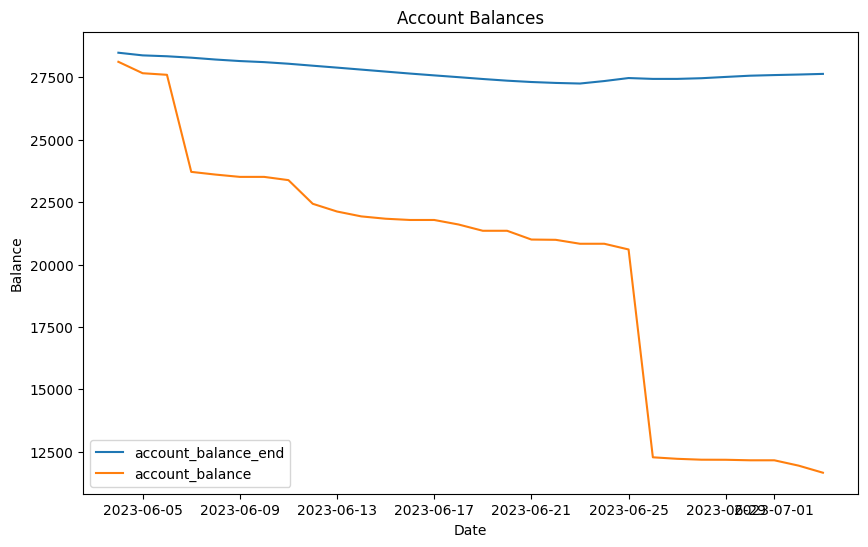

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a column in both DataFrames
plt.figure(figsize=(10, 6))
plt.plot(account_balance_end_train_2['date'][-30:], account_balance_end_train_2['balance'][-30:], label='account_balance_end')
plt.plot(account_balance['date'][-60:-30], account_balance['balance'][-60:-30], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances')
plt.legend()
plt.show()

In [ ]:
# Third part of 30-30-30 training for 90 days forecasting
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from datetime import datetime

def feature_creation(account_id, account_balance_):
    #account_balance = account_balances.get(account_id)
    #account_balance_=account_balance.copy()

    if account_balance_ is not None:
        # Add features: previous day, two days before, three days before, seven days before
        for i in range(1, 8):  # Adding lags from 1 to 7
            account_balance_[f'lag_{i}'] = account_balance_['balance'].shift(i)

        # Calculate last 5 days mean and standard deviation
        account_balance_['last_5_days_std'] = account_balance_['balance'].rolling(window=5).std()
        account_balance_['last_30_days_std'] = account_balance_['balance'].rolling(window=30).std()
        account_balance_['last_30_days_mean'] = account_balance_['balance'].rolling(window=30).mean()
        # Calculate the average of values for the 30th and 31st day before
        account_balance_['average_value_30_31'] = account_balance_['balance'].iloc[-30:-28].mean()
        account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)



        # Remove rows with missing values after feature engineering
        account_balance_.dropna(inplace=True)

        # Standardize the data
        # scaler_X = StandardScaler()
        # scaler_y = StandardScaler()
        X = account_balance_[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std', 'last_30_days_std', 'last_30_days_mean', 'average_value_30_31', 'day_of_week', 'is_weekend']]

        y = account_balance_['balance']
        y =y.values.reshape(-1, 1)
        return account_balance_,X,y

def model_creation(X_train, y_train):
  # Build the MLP model
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='mean_squared_error', optimizer=optimizer)

    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2)

    return model

def predict_one_day(X_test_, y_test_,model):

    y_pred = model.predict(X_test_)

    # Inverse transform to get actual values
    #y_test = scaler_y.inverse_transform(y_test_use)
    #y_pred = scaler_y.inverse_transform(y_pred)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test_, y_pred))
    print(f'Root Mean Squared Error (RMSE): {rmse}')

    return y_pred, rmse

# Write the account which will be forecasted
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
account_balance = account_balances.get(account_id)
account_balance_ = account_balance.copy()
#account_balance_=account_balance_.iloc[:-30]
account_balance_end=account_balance.copy()
# İlk 31 satırı çıkarmak için:
#account_balance_end = account_balance_end.iloc[31:]
train_size_2 = len(account_balance_end ) - 30
account_balance_end_train, account_balance_end_test = account_balance_end[:train_size_2], account_balance_end[train_size_2:(train_size_2+30)]
#standard scaler bak
account_balance_, X, y = feature_creation(account_id, account_balance_)
num=0
rmse_sum=0
if len(X) >= 30:
  train_size = len(X) - 30
  X_train, X_test = X[:train_size], X[train_size:]
  y_train, y_test = y[:train_size], y[train_size:]
  model=model_creation(X_train,y_train)
  for i in range(30):
        num=num+1
        # Set the train size to leave exactly 30 data points for the test set

          # Define your column names
        columns = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'last_5_days_std','last_30_days_std','last_30_days_mean','average_value_30_31','day_of_week', 'is_weekend']

        # Define the initial values for each column
        #iki nokta
        #account_balance_['day_of_week'] = account_balance_['date'].dt.dayofweek
        date = account_balance_end_test['date'].iloc[num-1]
        day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        is_weekend = 1 if date.weekday() >= 5 else 0

        #account_balance_['is_weekend'] = (account_balance_['day_of_week'] >= 5).astype(int)
        values = [account_balance_end_train['balance'].iloc[-1], account_balance_end_train['balance'].iloc[-2],
                  account_balance_end_train['balance'].iloc[-3],account_balance_end_train['balance'].iloc[-4],
                  account_balance_end_train['balance'].iloc[-5],account_balance_end_train['balance'].iloc[-6],
                  account_balance_end_train['balance'].iloc[-7],account_balance_end_train['balance'].tail(5).std(),
                  account_balance_end_train['balance'].tail(30).std(),account_balance_end_train['balance'].tail(30).mean(),
                  account_balance_end_train['balance'].iloc[-30:-28].mean(),day_of_week,is_weekend]

        # Create a dictionary where keys are column names and values are lists of corresponding values
        data = {col: [val] for col, val in zip(columns, values)}


        # Create the DataFrame
        df = pd.DataFrame(data)
        x_test_new=df.values
        y_test_new=y_test[num-1]

        x_test_new = x_test_new.reshape(1, -1)  # Reshape X_test_ to have shape (1, num_features)
        y_test_new = y_test_new.reshape(1, -1)
        y_pred, rmse=predict_one_day(x_test_new, y_test_new,model)
        #new_row = {'date': account_balance_end_test['date'].iloc[num-1], 'balance': y_pred}
        new_row = pd.DataFrame({'date': [account_balance_end_test['date'].iloc[num-1]], 'balance': [y_pred[0][0]]})
        # Appending the new row
        account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
        rmse_sum=rmse_sum+rmse

else:
          print("Not enough data points to create a test set with 30 data points.")
          #continue

Epoch 1/100
17/17 [==============================] - 1s 9ms/step - loss: 35513180160.0000 - val_loss: 27104802.0000
Epoch 2/100
17/17 [==============================] - 0s 2ms/step - loss: 1195104512.0000 - val_loss: 175255216.0000
Epoch 3/100
17/17 [==============================] - 0s 3ms/step - loss: 404804224.0000 - val_loss: 8015064.5000
Epoch 4/100
17/17 [==============================] - 0s 3ms/step - loss: 107746984.0000 - val_loss: 21212250.0000
Epoch 5/100
17/17 [==============================] - 0s 2ms/step - loss: 13390788.0000 - val_loss: 13030473.0000
Epoch 6/100
17/17 [==============================] - 0s 2ms/step - loss: 8212925.0000 - val_loss: 14066882.0000
Epoch 7/100
17/17 [==============================] - 0s 4ms/step - loss: 6659896.5000 - val_loss: 13731445.0000
Epoch 8/100
17/17 [==============================] - 0s 3ms/step - loss: 6507296.0000 - val_loss: 12329994.0000
Epoch 9/100
17/17 [==============================] - 0s 2ms/step - loss: 6439939.5000 - val_

<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 7289.09107421875
1/1 [==============================] - 0s 16ms/step
Root Mean Squared Error (RMSE): 8482.249926757811
1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 9835.022444152832
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 11154.259487304687
1/1 [==============================] - 0s 14ms/step
Root Mean Squared Error (RMSE): 11855.426787109374


<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 15ms/step
Root Mean Squared Error (RMSE): 12369.259462890624
1/1 [==============================] - 0s 13ms/step
Root Mean Squared Error (RMSE): 12664.90390625
1/1 [==============================] - 0s 17ms/step
Root Mean Squared Error (RMSE): 12494.013037109375
1/1 [==============================] - 0s 16ms/step
Root Mean Squared Error (RMSE): 11757.572480468749


...

<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)


1/1 [==============================] - 0s 30ms/step
Root Mean Squared Error (RMSE): 712.9934106445312
1/1 [==============================] - 0s 27ms/step
Root Mean Squared Error (RMSE): 642.4284844970703
1/1 [==============================] - 0s 21ms/step
Root Mean Squared Error (RMSE): 525.5303750610351
1/1 [==============================] - 0s 18ms/step
Root Mean Squared Error (RMSE): 363.16718536376953


<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_e

1/1 [==============================] - 0s 19ms/step
Root Mean Squared Error (RMSE): 72.40873718261719
1/1 [==============================] - 0s 20ms/step
Root Mean Squared Error (RMSE): 77.0784912109375
1/1 [==============================] - 0s 21ms/step
Root Mean Squared Error (RMSE): 307.77177978515624


<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)
<ipython-input-26-a129b0d5660c>:133: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance_end_train = account_balance_end_train.append(new_row, ignore_index=True)


In [ ]:
  account_balance_end_train_3=account_balance_end_train
  rmse_3=rmse_sum
  print(account_balance_end_train_3)

          date        balance
0   2021-07-27  310003.970000
1   2021-07-28  309347.500000
2   2021-07-29  309315.280000
3   2021-07-30  309267.530000
4   2021-07-31  309267.530000
..         ...            ...
732 2023-07-29    -117.470375
733 2023-07-30      44.892815
734 2023-07-31     193.091263
735 2023-08-01     342.578491
736 2023-08-02     363.011780

[737 rows x 2 columns]


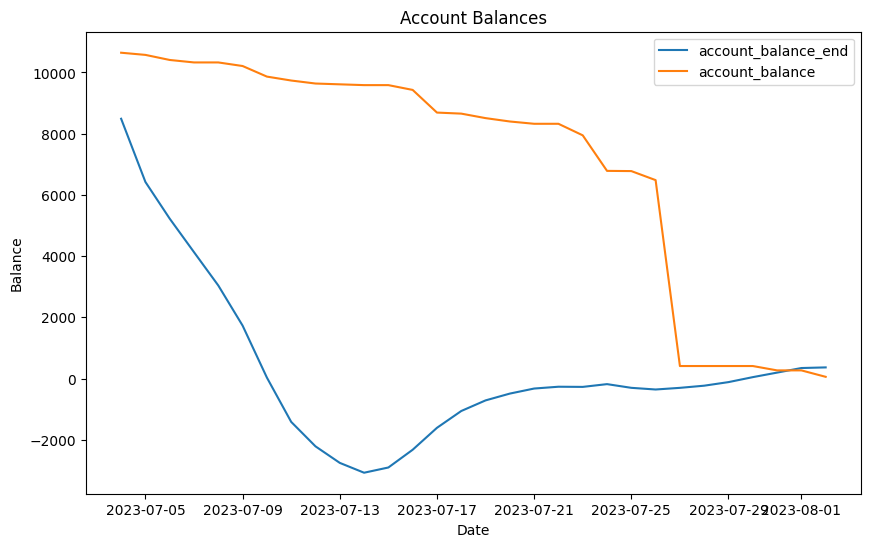

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a column in both DataFrames
plt.figure(figsize=(10, 6))
plt.plot(account_balance_end_train_3['date'][-30:], account_balance_end_train_3['balance'][-30:], label='account_balance_end')
plt.plot(account_balance['date'][-30:], account_balance['balance'][-30:], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances')
plt.legend()
plt.show()

In [ ]:
result = pd.concat([account_balance_end_train_1, account_balance_end_train_2[-30:]])
result=pd.concat([result, account_balance_end_train_3[-30:]])

In [ ]:
rmse_last=(rmse_1+rmse_2+rmse_3)/90
print(rmse_last)

12323.942612877736


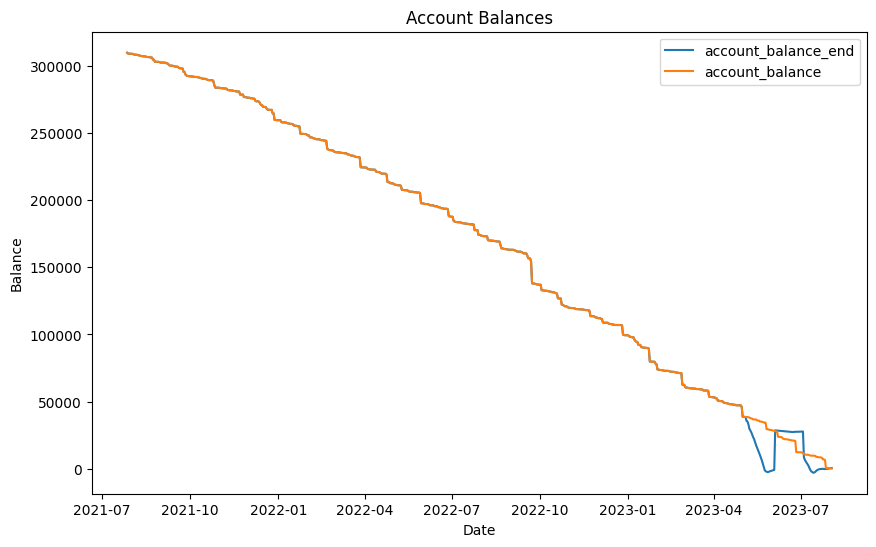

In [ ]:
# Plot to display complete forecasting
import matplotlib.pyplot as plt

# Assuming 'date' is a column in both DataFrames
plt.figure(figsize=(10, 6))
plt.plot(result['date'], result['balance'], label='account_balance_end')
plt.plot(account_balance['date'], account_balance['balance'], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances')
plt.legend()
plt.show()

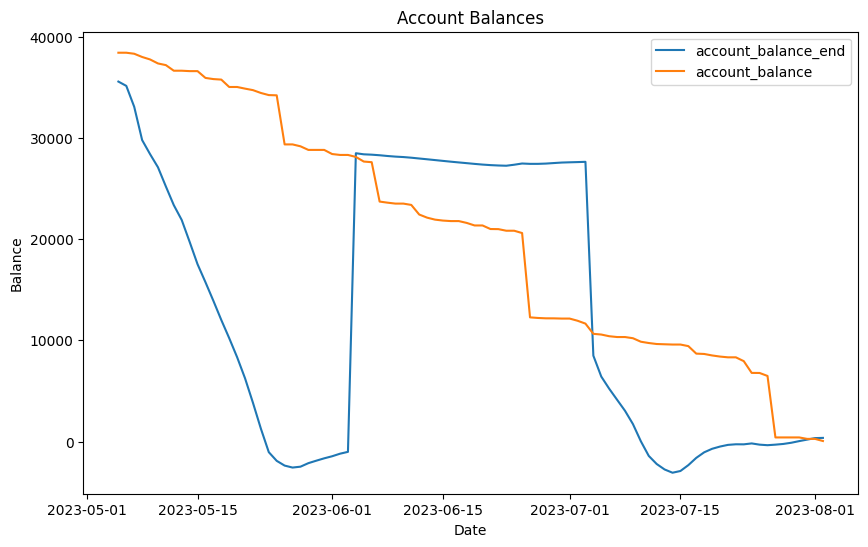

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'date' is a column in both DataFrames
plt.figure(figsize=(10, 6))
plt.plot(result['date'][-90:], result['balance'][-90:], label='account_balance_end')
plt.plot(account_balance['date'][-90:], account_balance['balance'][-90:], label='account_balance')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.title('Account Balances')
plt.legend()
plt.show()

In [ ]:
# Hyperparameter Tunning

def model_creation(X_train, y_train, learning_rate, batch_size):
    model = Sequential([
        Dense(64, activation='relu', input_dim=X_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mean_squared_error', optimizer=optimizer)

    model.fit(X_train, y_train, epochs=100, batch_size=batch_size, verbose=1, validation_split=0.2)

    return model

def time_series_cross_validation(X, y, k=5, learning_rate=0.001, batch_size=32):
    fold_size = len(X) // k
    rmse_scores = []

    for fold in range(1, k+1):
        print(f"Fold {fold}/{k}")

        train_size = fold_size * fold
        validation_size = train_size + fold_size

        X_train_fold = X[:train_size]
        y_train_fold = y[:train_size]
        X_val_fold = X[train_size:validation_size]
        y_val_fold = y[train_size:validation_size]

        model = model_creation(X_train_fold, y_train_fold, learning_rate, batch_size)

        y_pred = model.predict(X_val_fold)
        rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

# Define hyperparameters to tune
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [16, 32, 64]

best_rmse = float('inf')
best_params = {}

# Grid search
for lr in learning_rates:
    for batch in batch_sizes:
        print(f"Evaluating model with learning rate: {lr} and batch size: {batch}")
        avg_rmse = time_series_cross_validation(X, y, k=5, learning_rate=lr, batch_size=batch)

        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = {'learning_rate': lr, 'batch_size': batch}

print(f"Best parameters found: Learning Rate {best_params['learning_rate']} with Batch Size {best_params['batch_size']}. RMSE: {best_rmse}")


Görüntülenen çıkış son 5000 satıra kısaltıldı.
Epoch 74/100
18/18 [==============================] - 0s 3ms/step - loss: 2504632.0000 - val_loss: 1873835.7500
Epoch 75/100
18/18 [==============================] - 0s 3ms/step - loss: 2452580.7500 - val_loss: 1835830.5000
Epoch 76/100
18/18 [==============================] - 0s 3ms/step - loss: 2414149.0000 - val_loss: 1798009.8750
Epoch 77/100
18/18 [==============================] - 0s 4ms/step - loss: 2458730.0000 - val_loss: 1817935.3750
Epoch 78/100
18/18 [==============================] - 0s 3ms/step - loss: 2420398.0000 - val_loss: 1749226.2500
Epoch 79/100
18/18 [==============================] - 0s 3ms/step - loss: 2444423.7500 - val_loss: 1746028.0000
Epoch 80/100
18/18 [==============================] - 0s 4ms/step - loss: 2260180.7500 - val_loss: 1696078.8750
Epoch 81/100
18/18 [==============================] - 0s 4ms/step - loss: 2201128.0000 - val_loss: 1718128.3750
Epoch 82/100
18/18 [==============================] - 0s 

KeyboardInterrupt: ignored

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2684
[LightGBM] [Info] Number of data points in the train set: 404, number of used features: 22
[LightGBM] [Info] Start training from score 140217.464206
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

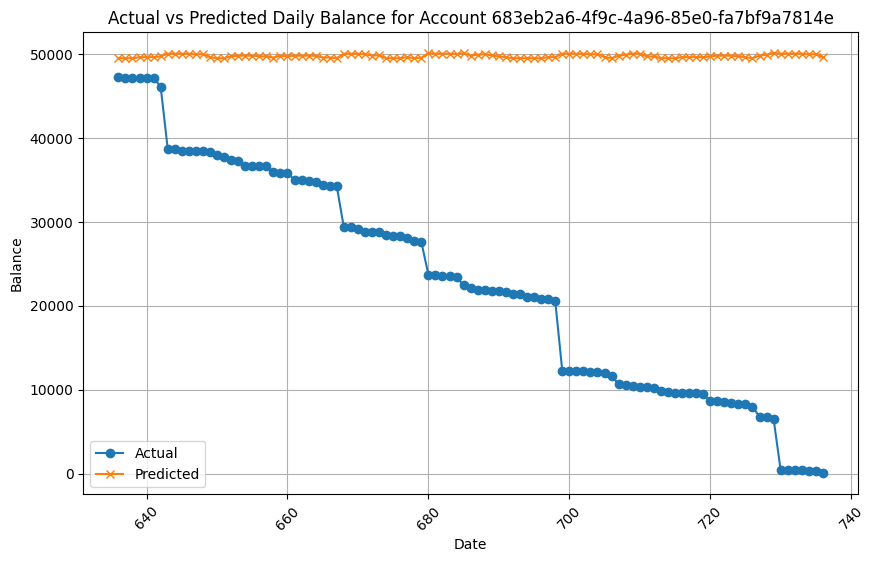

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2165
[LightGBM] [Info] Number of data points in the train set: 323, number of used features: 22
[LightGBM] [Info] Start training from score 138949.897349
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [ ]:
#Forming feature importance map
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import numpy as np
from lightgbm.callback import early_stopping

# Assuming you have account_balances available

# Function to perform time series forecasting using LightGBM
def perform_time_series_forecasting(account_id):
    account_balance = account_balances.get(account_id)

    if account_balance is not None:
        # Add features: previous day, two days before, three days before, seven days before
        account_balance['lag_1'] = account_balance['balance'].shift(1)
        account_balance['lag_2'] = account_balance['balance'].shift(2)
        account_balance['lag_3'] = account_balance['balance'].shift(3)
        account_balance['lag_4'] = account_balance['balance'].shift(4)
        account_balance['lag_5'] = account_balance['balance'].shift(5)
        account_balance['lag_6'] = account_balance['balance'].shift(6)
        account_balance['lag_7'] = account_balance['balance'].shift(7)
        account_balance['lag_8'] = account_balance['balance'].shift(8)
        account_balance['lag_9'] = account_balance['balance'].shift(9)
        account_balance['lag_10'] = account_balance['balance'].shift(10)

        # Calculate last 5 days mean and standard deviation
        account_balance['last_5_days_std'] = account_balance['balance'].rolling(window=5).std()
        account_balance['last_4_days_std'] = account_balance['balance'].rolling(window=4).std()
        account_balance['last_6_days_std'] = account_balance['balance'].rolling(window=6).std()
        account_balance['last_7_days_std'] = account_balance['balance'].rolling(window=7).std()
        account_balance['last_30_days_std'] = account_balance['balance'].rolling(window=30).std()

        account_balance['last_5_days_mean'] = account_balance['balance'].rolling(window=5).mean()
        account_balance['last_4_days_mean'] = account_balance['balance'].rolling(window=4).mean()
        account_balance['last_6_days_mean'] = account_balance['balance'].rolling(window=6).mean()
        account_balance['last_7_days_mean'] = account_balance['balance'].rolling(window=7).mean()
        account_balance['last_30_days_mean'] = account_balance['balance'].rolling(window=30).mean()

        #day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        #is_weekend = 1 if date.weekday() >= 5 else 0
        account_balance['average_value_30_31'] = account_balance['balance'].iloc[-30:-28].mean()
        account_balance['day_of_week'] = account_balance['date'].dt.dayofweek
        account_balance['is_weekend'] = (account_balance['day_of_week'] >= 5).astype(int)

        # Remove rows with missing values after feature engineering
        account_balance.dropna(inplace=True)

        # Split data into train and test sets
        X = account_balance[['lag_1', 'lag_2',
                             'lag_3', 'lag_4',
                             'lag_5', 'lag_6',
                             'lag_7', 'lag_8',
                             'lag_9', 'lag_10',
                            'last_5_days_std',
                            'last_4_days_std',
                            'last_6_days_std',
                            'last_7_days_std',
                            'last_30_days_std',
                            'last_5_days_mean',
                            'last_4_days_mean',
                            'last_6_days_mean',
                            'last_7_days_mean',
                            'last_30_days_mean',
                             'average_value_30_31',
                             'day_of_week',
                             'is_weekend']]
        y = account_balance['balance']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        # Train LightGBM model
        params = {
            'boosting_type': 'gbdt',
            'objective': 'regression',
            'metric': 'rmse',
            'num_leaves': 31,
            'learning_rate': 0.05,
            'feature_fraction': 0.9
        }
        train_data = lgb.Dataset(X_train, label=y_train)
        stopping_callback = early_stopping(stopping_rounds=10, first_metric_only=False, verbose=True)

        model = lgb.train(params, train_data, num_boost_round=100)

        # Make predictions
        y_pred = model.predict(X_test)

        # Visualize actual vs predicted values
        plt.figure(figsize=(10, 6))
        plt.plot(account_balance.index[-len(y_test):], y_test.values, label='Actual', marker='o')
        plt.plot(account_balance.index[-len(y_test):], y_pred, label='Predicted', marker='x')
        plt.title(f'Actual vs Predicted Daily Balance for Account {account_id}')
        plt.xlabel('Date')
        plt.ylabel('Balance')
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)
        plt.show()

        # Create dataframes with actual and predicted values
        df_actual_predicted = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})

        return df_actual_predicted, X_train, y_train, model
    else:
        print(f'Account ID {account_id} not found in account_balances.')
        return None, None, None, None

# Example usage for account_id
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
df_actual_predicted, X_train, y_train, model = perform_time_series_forecasting(account_id)

# Now, df_actual_predicted contains the actual and predicted values for daily balance, you can further extend this for inflow/outflow

# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_rmse = []

for train_index, val_index in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    params = {
        'boosting_type': 'gbdt',
        'objective': 'regression',
        'metric': 'rmse',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9
    }

    #model = lgb.train(params, train_data, num_boost_round=100, valid_sets=[val_data], early_stopping_rounds=10, verbose_eval=10)
    stopping_callback = early_stopping(stopping_rounds=10, first_metric_only=False, verbose=True)
    model = lgb.train(params, train_data, num_boost_round=100, valid_sets=[val_data], callbacks=[stopping_callback])

    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    all_rmse.append(rmse)

# Print cross-validation results
print(f'Average RMSE across folds: {np.mean(all_rmse)}')


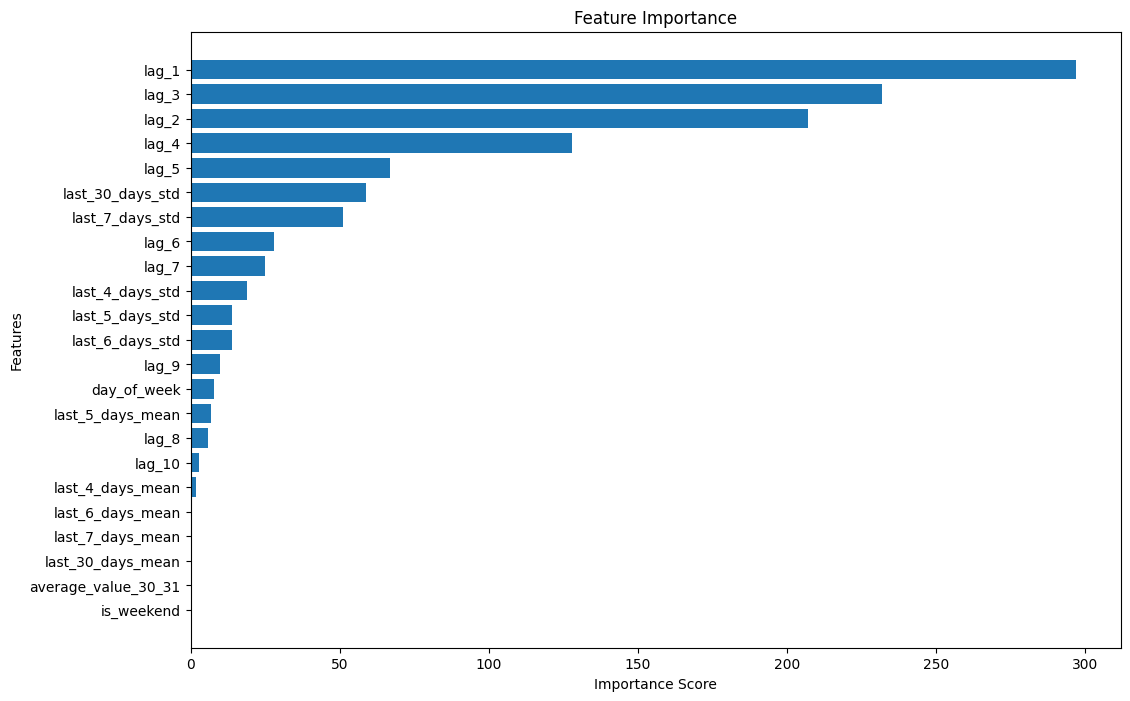

In [ ]:
import matplotlib.pyplot as plt

# Fetch the feature importance from the LightGBM model
importance = model.feature_importance()

# Fetch the feature names
feature_names = model.feature_name()

# Combine feature names with their importance scores
feature_importance = list(zip(feature_names, importance))

# Sort features by importance in descending order
feature_importance.sort(key=lambda x: x[1], reverse=True)

# Separate features and their importance for plotting
sorted_feature_names = [x[0] for x in feature_importance]
sorted_importance = [x[1] for x in feature_importance]

# Create a bar plot for feature importance
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names[::-1], sorted_importance[::-1])  # We reverse lists to have the feature with highest importance on top
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()


[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1427
[LightGBM] [Info] Number of data points in the train set: 427, number of used features: 12
[LightGBM] [Info] Start training from score 148144.744895
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

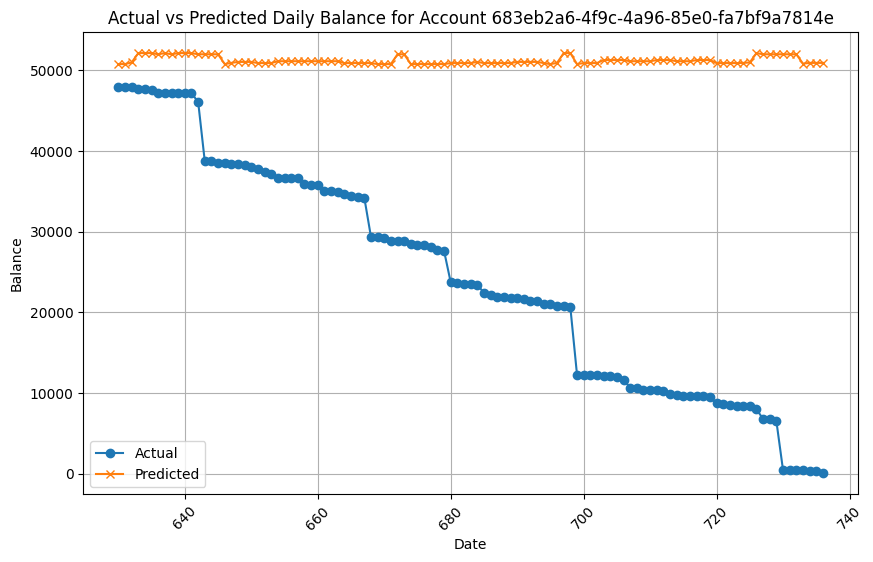

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1147
[LightGBM] [Info] Number of data points in the train set: 341, number of used features: 12
[LightGBM] [Info] Start training from score 146565.328778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [ ]:
#Feature importance map after selecting appopriate features
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
import numpy as np
from lightgbm.callback import early_stopping

# Assuming you have account_balances available

# Function to perform time series forecasting using LightGBM
def perform_time_series_forecasting(account_id):
    account_balance = account_balances.get(account_id)

    if account_balance is not None:
        # Add features: previous day, two days before, three days before, seven days before
        account_balance['lag_1'] = account_balance['balance'].shift(1)
        account_balance['lag_2'] = account_balance['balance'].shift(2)
        account_balance['lag_3'] = account_balance['balance'].shift(3)
        account_balance['lag_4'] = account_balance['balance'].shift(4)
        account_balance['lag_5'] = account_balance['balance'].shift(5)
        account_balance['lag_6'] = account_balance['balance'].shift(6)
        account_balance['lag_7'] = account_balance['balance'].shift(7)

        # Calculate last 5 days mean and standard deviation
        account_balance['last_5_days_std'] = account_balance['balance'].rolling(window=5).std()
        account_balance['last_30_days_std'] = account_balance['balance'].rolling(window=30).std()
        account_balance['last_30_days_mean'] = account_balance['balance'].rolling(window=30).mean()

        #day_of_week = date.weekday()  # Monday is 0 and Sunday is 6
        #is_weekend = 1 if date.weekday() >= 5 else 0
        account_balance['average_value_30_31'] = account_balance['balance'].iloc[-30:-28].mean()
        account_balance['day_of_week'] = account_balance['date'].dt.dayofweek
        account_balance['is_weekend'] = (account_balance['day_of_week'] >= 5).astype(int)

        # Remove rows with missing values after feature engineering
        account_balance.dropna(inplace=True)

        # Split data into train and test sets
        X = account_balance[['lag_1', 'lag_2',
                             'lag_3', 'lag_4',
                             'lag_5', 'lag_6',
                             'lag_7',
                            'last_5_days_std',
                            'last_30_days_std',
                            'last_30_days_mean',
                             'average_value_30_31',
                             'day_of_week',
                             'is_weekend']]
        y = account_balance['balance']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        # Train LightGBM model
        params = {
            'boosting_type': 'gbdt',
            'objective': 'regression',
            'metric': 'rmse',
            'num_leaves': 31,
            'learning_rate': 0.05,
            'feature_fraction': 0.9
        }
        train_data = lgb.Dataset(X_train, label=y_train)
        stopping_callback = early_stopping(stopping_rounds=10, first_metric_only=False, verbose=True)

        model = lgb.train(params, train_data, num_boost_round=100)

        # Make predictions
        y_pred = model.predict(X_test)

        # Visualize actual vs predicted values
        plt.figure(figsize=(10, 6))
        plt.plot(account_balance.index[-len(y_test):], y_test.values, label='Actual', marker='o')
        plt.plot(account_balance.index[-len(y_test):], y_pred, label='Predicted', marker='x')
        plt.title(f'Actual vs Predicted Daily Balance for Account {account_id}')
        plt.xlabel('Date')
        plt.ylabel('Balance')
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)
        plt.show()

        # Create dataframes with actual and predicted values
        df_actual_predicted = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})

        return df_actual_predicted, X_train, y_train, model
    else:
        print(f'Account ID {account_id} not found in account_balances.')
        return None, None, None, None

# Example usage for account_id
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
df_actual_predicted, X_train, y_train, model = perform_time_series_forecasting(account_id)

# Now, df_actual_predicted contains the actual and predicted values for daily balance, you can further extend this for inflow/outflow

# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_rmse = []

for train_index, val_index in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    train_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    params = {
        'boosting_type': 'gbdt',
        'objective': 'regression',
        'metric': 'rmse',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9
    }

    #model = lgb.train(params, train_data, num_boost_round=100, valid_sets=[val_data], early_stopping_rounds=10, verbose_eval=10)
    stopping_callback = early_stopping(stopping_rounds=10, first_metric_only=False, verbose=True)
    model = lgb.train(params, train_data, num_boost_round=100, valid_sets=[val_data], callbacks=[stopping_callback])

    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    all_rmse.append(rmse)

# Print cross-validation results
print(f'Average RMSE across folds: {np.mean(all_rmse)}')


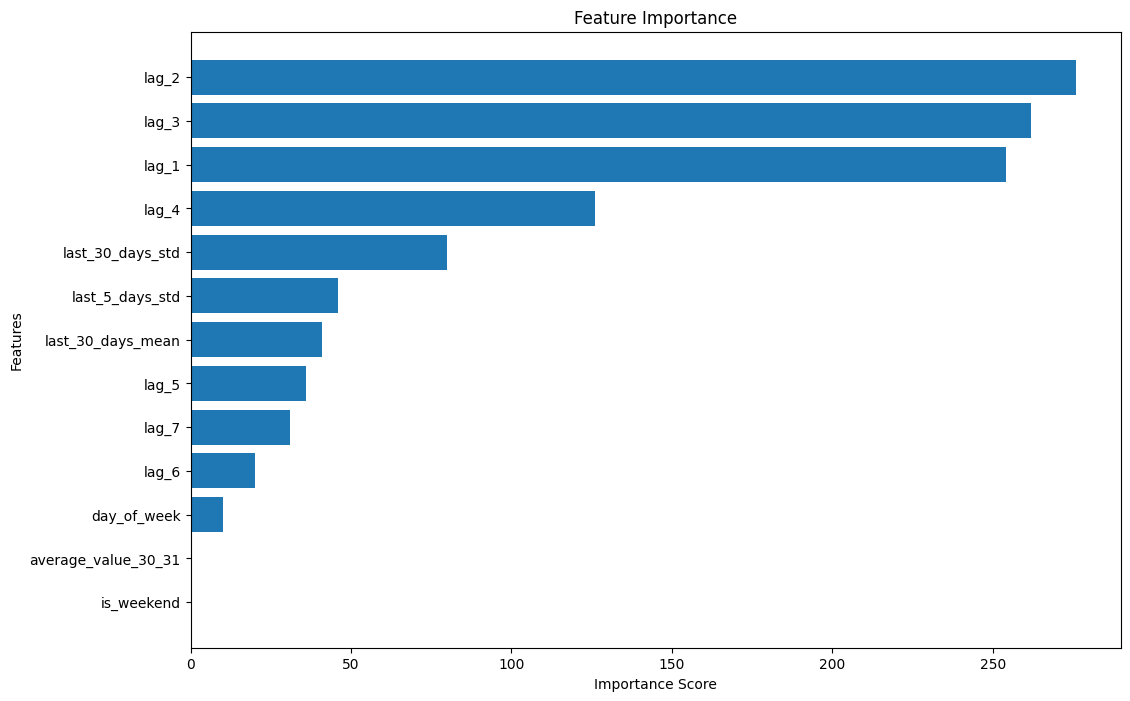

In [ ]:
import matplotlib.pyplot as plt

# Fetch the feature importance from the LightGBM model
importance = model.feature_importance()

# Fetch the feature names
feature_names = model.feature_name()

# Combine feature names with their importance scores
feature_importance = list(zip(feature_names, importance))

# Sort features by importance in descending order
feature_importance.sort(key=lambda x: x[1], reverse=True)

# Separate features and their importance for plotting
sorted_feature_names = [x[0] for x in feature_importance]
sorted_importance = [x[1] for x in feature_importance]

# Create a bar plot for feature importance
plt.figure(figsize=(12, 8))
plt.barh(sorted_feature_names[::-1], sorted_importance[::-1])  # We reverse lists to have the feature with highest importance on top
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()
